# Comparison with SPARQL work

We compare PGProv with NPCS, the most recent provenance framework for SPARQL. However, due to fundamental differences between the RDF and LPG data models, a direct experimental comparison is challenging.
For this evaluation, we use the WatDiv 10M dataset. This RDF dataset is transformed into an LPG representation using NeoSemantics. NPCS is executed using the named graphs reification scheme, which has been reported to provide the best performance in GraphDB. The SPARQL benchmark queries were manually translated into GQL based on the transformed LPG schema.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams["font.family"] = "DejaVu Serif"

pd.set_option('display.float_format', '{:.0f}'.format)

plt.style.use("default")
plt.rcParams.update({
    "font.size": 14,
    "figure.facecolor": "white",
    "axes.facecolor": "white",
    "savefig.facecolor": "white"
})

## PGProv vs NPCS Overhead Comparison

In [2]:
mapping = {
    "queries/watdivqueries/Basic/C1": 1,
    "queries/watdivqueries/Basic/C2": 2,
    "queries/watdivqueries/Basic/C3": 3,
    "queries/watdivqueries/Basic/F1": 4,
    "queries/watdivqueries/Basic/F2": 5,
    "queries/watdivqueries/Basic/F3": 6,
    "queries/watdivqueries/Basic/F4": 7,
    "queries/watdivqueries/Basic/F5": 8,
    "queries/watdivqueries/Basic/L1": 9,
    "queries/watdivqueries/Basic/L2": 10,
    "queries/watdivqueries/Basic/L3": 11,
    "queries/watdivqueries/Basic/L4": 12,
    "queries/watdivqueries/Basic/L5": 13,
    "queries/watdivqueries/Basic/S1": 14,
    "queries/watdivqueries/Basic/S2": 15,
    "queries/watdivqueries/Basic/S3": 16,
    "queries/watdivqueries/Basic/S4": 17,
    "queries/watdivqueries/Basic/S5": 18,
    "queries/watdivqueries/Basic/S6": 19,
    "queries/watdivqueries/Basic/S7": 20
}


# Processing NPCS
npcs = pd.read_csv(
    'result/npcs_4.csv',
    sep=",",
    dtype={"scale_factor": "float64"},
)

npcs_orig = pd.read_csv(
    'result/npcs_orig.csv',
    sep=",",
    dtype={"scale_factor": "float64"},
)


npcs["total_exec_time"] = np.where(
    npcs["QueryType"] == "Namedgraph",
    npcs["RewritingTime(ms)"] + npcs["ExecutionTime(ms)"],
    npcs["ExecutionTime(ms)"]
)

# Processing PGProv
pgprov_orig = pd.read_csv(
    'result/2026-05-28_watdiv_10_latency.csv',
    sep=",",
    dtype={"scale_factor": "float64"},
)
pgprov_orig[["query_type", "query_number"]] = pgprov_orig["query"].str.extract(
    r"^(.*?)-(\d+)_"
)
pgprov_orig["query_number"] = pgprov_orig["query_number"].astype(int)

pgprov_orig["query_type"] = pgprov_orig["query_type"].str.replace("_watdiv$", "", regex=True)
pgprov = pgprov_orig[(pgprov_orig["query_type"] == "prov") | (pgprov_orig["query_type"] == "orig")]
rewritten = pgprov_orig[(pgprov_orig["query_type"] == "rewritten") | (pgprov_orig["query_type"] == "orig")]

In [3]:
pgprov_pivoted = (
    pgprov.groupby(
        ['query_number', 'query_type'],
        as_index=False
    )['mean']
    .mean()
    .pivot(
        index=['query_number'],
        columns='query_type',
        values='mean'
    )
    .reset_index()
    .rename(columns={
        'rewritten':'prov'
    })
)

rewritten_pivoted = (
    rewritten.groupby(
        ['query_number', 'query_type'],
        as_index=False
    )['mean']
    .mean()
    .pivot(
        index=['query_number'],
        columns='query_type',
        values='mean'
    )
    .reset_index()
    .rename(columns={
        'rewritten':'prov'
    })
)

npcs_pivoted = (
    npcs.groupby(
        ['Folder', 'QueryType'],
        as_index=False
    )['total_exec_time']
    .mean()
    .pivot(
        index=['Folder'],
        columns='QueryType',
        values='total_exec_time'
    )
    .reset_index()
    .rename(columns={
        'Folder':'query_number',
        'Namedgraph':'prov'
    })
)

pgprov_pivoted['percentage_overhead'] = (pgprov_pivoted["prov"] - pgprov_pivoted["orig"])*100/pgprov_pivoted["orig"]
rewritten_pivoted['percentage_overhead'] = (rewritten_pivoted["prov"] - rewritten_pivoted["orig"])*100/rewritten_pivoted["orig"]

npcs_pivoted['percentage_overhead'] = (npcs_pivoted["prov"] - npcs_pivoted["orig"])*100/npcs_pivoted["orig"]
npcs_pivoted["query_number"] = npcs_pivoted["query_number"].replace(mapping)
npcs_mean = npcs_pivoted.groupby(["query_number"]).agg({"percentage_overhead":"mean"}).reindex()

npcs_orig['percentage_overhead'] = (npcs_orig["prov"] - npcs_orig["orig"])*100/npcs_orig["orig"]

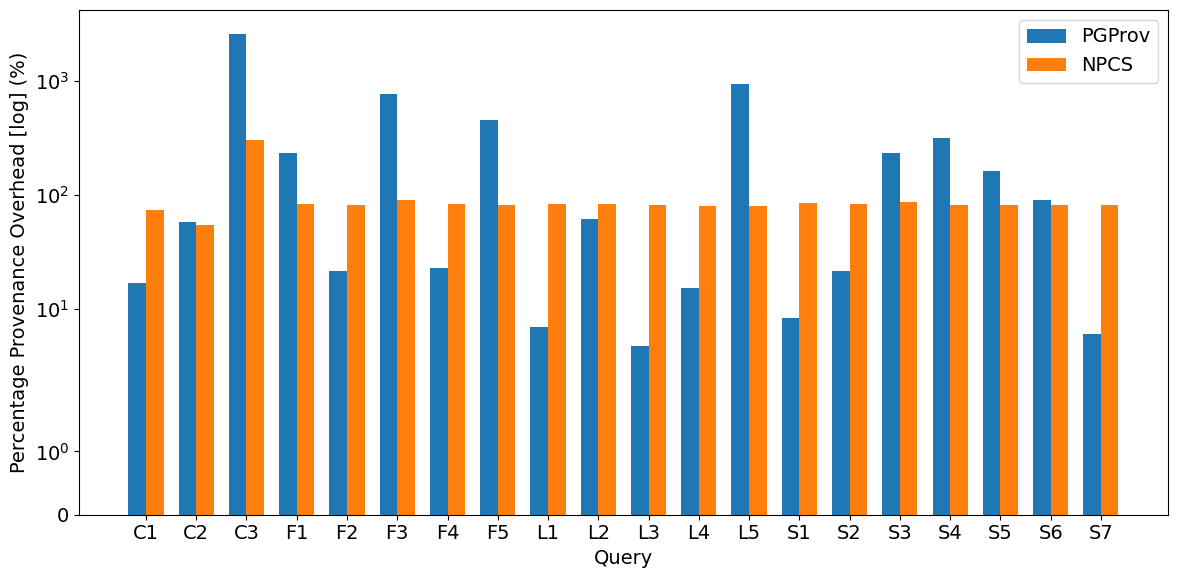

In [4]:
df_pgprov = pgprov_pivoted.rename(columns={"percentage_overhead": "PGProv"})
df_npcs   = npcs_mean.rename(columns={"percentage_overhead": "NPCS"})

mapping = {
    1:"C1",
    2:"C2",
    3:"C3",
    4:"F1",
    5:"F2",
    6:"F3",
    7:"F4",
    8:"F5",
    9:"L1",
    10:"L2",
    11:"L3",
    12:"L4",
    13:"L5",
    14:"S1",
    15:"S2",
    16:"S3",
    17:"S4",
    18:"S5",
    19:"S6",
    20:"S7",
}

df = pd.merge(df_pgprov, df_npcs, on="query_number")
df = df.sort_values("query_number")

x = np.arange(len(df["query_number"]))
width = 0.35

plt.figure(figsize=(12, 6))

plt.bar(x - (width/2), df["PGProv"], width, label="PGProv")
plt.bar(x + (width/2), df["NPCS"], width, label="NPCS")

plt.yscale("symlog")

plt.xlabel("Query")
plt.ylabel("Percentage Provenance Overhead [log] (%)")
plt.xticks(x, df["query_number"].map(mapping))
plt.legend()

plt.tight_layout()

# plt.savefig("result/plots/0519/overhead_comparison_wnpcs.png", dpi=300, bbox_inches="tight")
plt.show()


**Observations:**
* When comparing the two approaches, we observe that sometimes our overhead is larger, and sometimes smaller. We cannot establish a clear trend. It is hard to establish why this is observed, given the different data model.